In [13]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Path to dataset files:", path)


Path to dataset files: /Users/lmpierin/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1


In [4]:
np.random.seed(42)
df = pd.read_csv(os.path.join(path, "heart.csv"))
print("Dataset shape:", df.shape)
print("First 5 records:", df.head())

Dataset shape: (918, 12)
First 5 records:    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [32]:
df['Sex'] = df["Sex"].map({'M': 0, 'F': 1})
df['ChestPainType'] = df["ChestPainType"].map({'TA': 0, 'ATA': 1, 'NAP': 2, 'ASY': 3})
df['RestingECG'] = df["RestingECG"].map({'Normal': 0, 'ST': 1, 'LVH': 2})
df['ExerciseAngina'] = df["ExerciseAngina"].map({'N': 0, 'Y': 1})
df['ST_Slope'] = df["ST_Slope"].map({'Up': 0, 'Flat': 1, 'Down': 2})

X = df.drop("HeartDisease", axis=1 )
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10, 10),  # 3 hidden layers
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42, 
        verbose=True, 
        n_iter_no_change=20)

mlp.fit(X_train, y_train)


Iteration 1, loss = 15.57705102
Iteration 2, loss = 14.92121500
Iteration 3, loss = 13.81385085
Iteration 4, loss = 12.35780028
Iteration 5, loss = 10.70004262
Iteration 6, loss = 9.04590958
Iteration 7, loss = 7.46796101
Iteration 8, loss = 6.00654128
Iteration 9, loss = 4.68604961
Iteration 10, loss = 3.41070920
Iteration 11, loss = 1.95888794
Iteration 12, loss = 0.80399788
Iteration 13, loss = 0.99156857
Iteration 14, loss = 1.17901404
Iteration 15, loss = 0.84811144
Iteration 16, loss = 0.64595788
Iteration 17, loss = 0.72665369
Iteration 18, loss = 0.72702686
Iteration 19, loss = 0.65241789
Iteration 20, loss = 0.62683609
Iteration 21, loss = 0.64221794
Iteration 22, loss = 0.62023429
Iteration 23, loss = 0.60547185
Iteration 24, loss = 0.60707513
Iteration 25, loss = 0.60182873
Iteration 26, loss = 0.59326412
Iteration 27, loss = 0.59191640
Iteration 28, loss = 0.58771272
Iteration 29, loss = 0.58218112
Iteration 30, loss = 0.58095476
Iteration 31, loss = 0.57737238
Iteration 32

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [7]:
y_pred = mlp.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Acurácia: 0.8369565217391305

Matriz de Confusão:
[[62 15]
 [15 92]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        77
           1       0.86      0.86      0.86       107

    accuracy                           0.84       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [8]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=5000,
        random_state=42
    ))
])

# The dataset has only 11 input features and fewer than 1,000 rows,
# so compact, tapering architectures are a better starting point than very wide/deep ones.
param_grid = {
    "mlp__hidden_layer_sizes": [
        (2,),(4,),(6,),(8,),(12,),(16,),
        #(24,),(32,),(40,),(44,),(50,),
        (2, 2),
        (4, 2),(4, 4),
        (6, 2),(6, 4),(6, 6),(6, 8),
        (8, 4),(8, 8),(8, 12),
        (12, 6),(12, 12),(12, 16),
        (16, 8),(16, 16),(16, 24),
        (24, 12),(24, 24),(24, 32),
        #(32, 16),(32, 32),(32, 40),
        #(40, 20),(40, 40),(40, 50),
        #(44, 22),(44, 44),(44, 55),
        #(50, 25),(50, 50),(50, 60)
    ],
    "mlp__activation": ['relu', 'identity', 'logistic', 'tanh'],
    "mlp__solver": ['lbfgs', 'adam'],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 183 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learni

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 183 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learnin

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 178 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.4s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learnin

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 178 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 151 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 151 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_in

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_si

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.7s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   2.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_in

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.5s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_i

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.7s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.6s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_r

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4), mlp__learning_rate_init=0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.001

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   1.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, m

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['relu', 'identity', ...], 'mlp__alpha': [0.0001, 0.001, ...], 'mlp__hidden_layer_sizes': [(2,), (4,), ...], 'mlp__learning_rate_init': [0.001, 0.01], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``

In [10]:
print("Melhores parâmetros:")
print(grid_search.best_params_)

print("\nMelhor acurácia na validação holdout:")
print(grid_search.best_score_)

Melhores parâmetros:
{'mlp__activation': 'logistic', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (24, 12), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}

Melhor acurácia na validação holdout:
0.8637871586990962


In [11]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAcurácia no teste:")
print(accuracy_score(y_test, y_pred))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
))


Acurácia no teste:
0.8532608695652174

Matriz de confusão:
[[67 10]
 [17 90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



Text(0.5, 0.98, 'Distribuição de Colesterol')

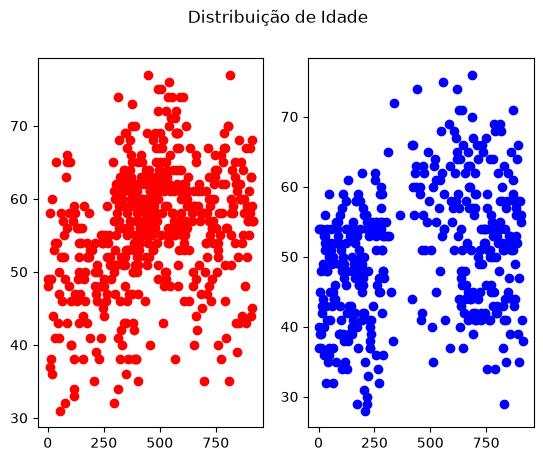

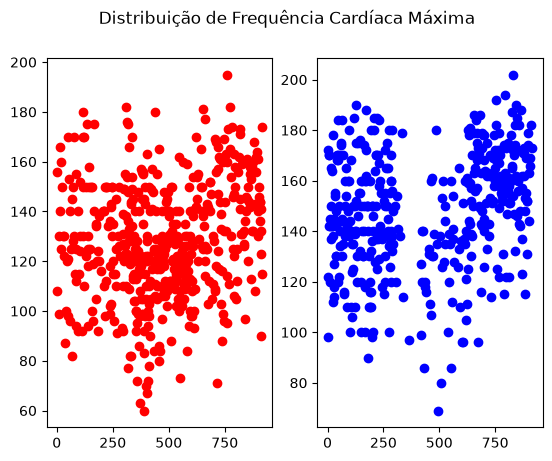

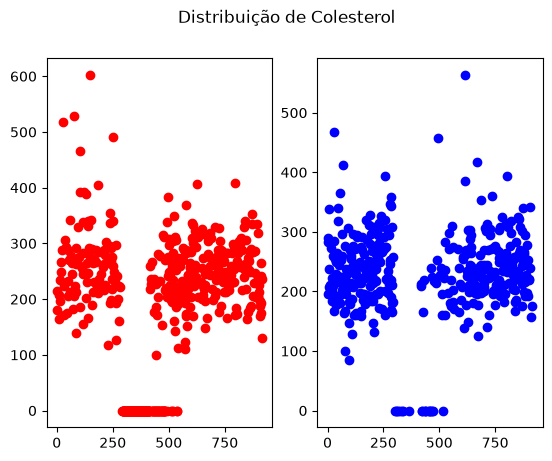

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(df['Age'].where(df['HeartDisease'] == 1), 'ro')
ax2.plot(df['Age'].where(df['HeartDisease'] == 0), 'bo')
fig.suptitle("Distribuição de Idade")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(df['MaxHR'].where(df['HeartDisease'] == 1), 'ro')
ax2.plot(df['MaxHR'].where(df['HeartDisease'] == 0), 'bo')
fig.suptitle("Distribuição de Frequência Cardíaca Máxima")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(df['Cholesterol'].where(df['HeartDisease'] == 1), 'ro')
ax2.plot(df['Cholesterol'].where(df['HeartDisease'] == 0), 'bo')
fig.suptitle("Distribuição de Colesterol")



In [34]:
#Remove the outliers from the dataset
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep rows where NO column value is an outlier
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


Text(0.5, 0.98, 'Distribuição de Colesterol')

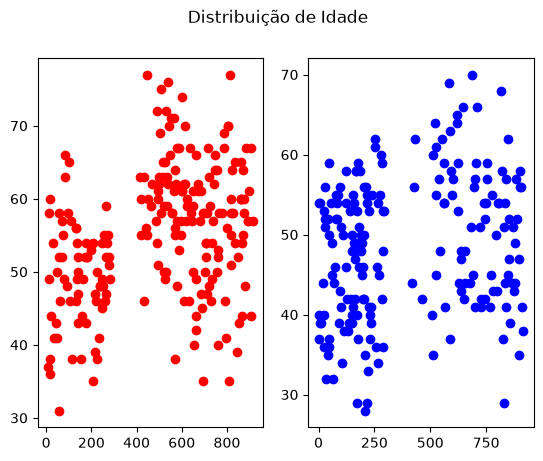

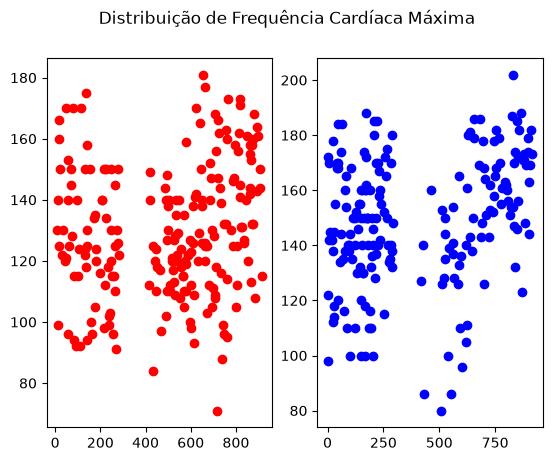

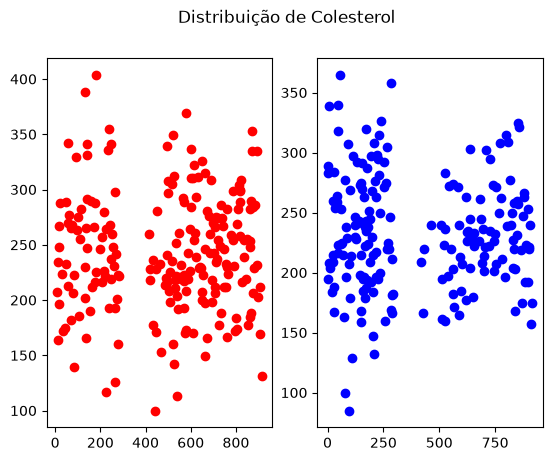

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(df_cleaned['Age'].where(df_cleaned['HeartDisease'] == 1), 'ro')
ax2.plot(df_cleaned['Age'].where(df_cleaned['HeartDisease'] == 0), 'bo')
fig.suptitle("Distribuição de Idade")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(df_cleaned['MaxHR'].where(df_cleaned['HeartDisease'] == 1), 'ro')
ax2.plot(df_cleaned['MaxHR'].where(df_cleaned['HeartDisease'] == 0), 'bo')
fig.suptitle("Distribuição de Frequência Cardíaca Máxima")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(df_cleaned['Cholesterol'].where(df_cleaned['HeartDisease'] == 1), 'ro')
ax2.plot(df_cleaned['Cholesterol'].where(df_cleaned['HeartDisease'] == 0), 'bo')
fig.suptitle("Distribuição de Colesterol")

In [37]:
X2 = df_cleaned.drop("HeartDisease", axis=1 )
y2 = df_cleaned["HeartDisease"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [38]:
mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10, 10),  # 3 hidden layers
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42, 
        verbose=True, 
        n_iter_no_change=20)

mlp.fit(X2_train, y2_train)

Iteration 1, loss = 18.05996406
Iteration 2, loss = 17.88877185
Iteration 3, loss = 17.65496802
Iteration 4, loss = 17.23919184
Iteration 5, loss = 16.67912489
Iteration 6, loss = 15.99828025
Iteration 7, loss = 15.18882707
Iteration 8, loss = 14.27054477
Iteration 9, loss = 13.36204763
Iteration 10, loss = 12.40373111
Iteration 11, loss = 11.47638466
Iteration 12, loss = 10.59832371
Iteration 13, loss = 9.70161664
Iteration 14, loss = 8.82196266
Iteration 15, loss = 7.95761682
Iteration 16, loss = 7.12990438
Iteration 17, loss = 6.27807170
Iteration 18, loss = 5.41390152
Iteration 19, loss = 4.50753973
Iteration 20, loss = 3.58161071
Iteration 21, loss = 2.55653689
Iteration 22, loss = 1.55712294
Iteration 23, loss = 0.87614893
Iteration 24, loss = 0.78049189
Iteration 25, loss = 1.11442093
Iteration 26, loss = 1.37002205
Iteration 27, loss = 1.41703825
Iteration 28, loss = 1.28556057
Iteration 29, loss = 1.05086176
Iteration 30, loss = 0.80721447
Iteration 31, loss = 0.68014847
Itera

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [39]:
y2_pred = mlp.predict(X2_test)

print("Acurácia:", accuracy_score(y2_test, y2_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y2_test, y2_pred))

print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

Acurácia: 0.7349397590361446

Matriz de Confusão:
[[29  6]
 [16 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.83      0.72        35
           1       0.84      0.67      0.74        48

    accuracy                           0.73        83
   macro avg       0.74      0.75      0.73        83
weighted avg       0.76      0.73      0.74        83



In [40]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=5000,
        random_state=42
    ))
])

# The dataset has only 11 input features and fewer than 1,000 rows,
# so compact, tapering architectures are a better starting point than very wide/deep ones.
param_grid = {
    "mlp__hidden_layer_sizes": [
        (2,),(4,),(6,),(8,),(12,),(16,),
        #(24,),(32,),(40,),(44,),(50,),
        (2, 2),
        (4, 2),(4, 4),
        (6, 2),(6, 4),(6, 6),(6, 8),
        (8, 4),(8, 8),(8, 12),
        (12, 6),(12, 12),(12, 16),
        (16, 8),(16, 16),(16, 24),
        (24, 12),(24, 24),(24, 32),
        #(32, 16),(32, 32),(32, 40),
        #(40, 20),(40, 40),(40, 50),
        #(44, 22),(44, 44),(44, 55),
        #(50, 25),(50, 50),(50, 60)
    ],
    "mlp__activation": ['relu', 'identity', 'logistic', 'tanh'],
    "mlp__solver": ['lbfgs', 'adam'],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X2_train, y2_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2,), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4), mlp__learning_rate_init=0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4), mlp__learning_rate_init=0.

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['relu', 'identity', ...], 'mlp__alpha': [0.0001, 0.001, ...], 'mlp__hidden_layer_sizes': [(2,), (4,), ...], 'mlp__learning_rate_init': [0.001, 0.01], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``

In [42]:
print("Melhores parâmetros:")
print(grid_search.best_params_)

print("\nMelhor acurácia na validação holdout:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y2_pred = best_model.predict(X2_test)

print("\nAcurácia no teste:")
print(accuracy_score(y2_test, y2_pred))

print("\nMatriz de confusão:")
print(confusion_matrix(y2_test, y2_pred))

print("\nClassification Report:")
print(classification_report(
    y2_test,
    y2_pred,
))

Melhores parâmetros:
{'mlp__activation': 'identity', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16, 16), 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'adam'}

Melhor acurácia na validação holdout:
0.8887381275440976

Acurácia no teste:
0.7710843373493976

Matriz de confusão:
[[30  5]
 [14 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.86      0.76        35
           1       0.87      0.71      0.78        48

    accuracy                           0.77        83
   macro avg       0.78      0.78      0.77        83
weighted avg       0.79      0.77      0.77        83



In [43]:
y3_pred = best_model.predict(X_test)

print("\nAcurácia no teste:")
print(accuracy_score(y_test, y3_pred))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y3_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y3_pred,
))


Acurácia no teste:
0.7934782608695652

Matriz de confusão:
[[68  9]
 [29 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78        77
           1       0.90      0.73      0.80       107

    accuracy                           0.79       184
   macro avg       0.80      0.81      0.79       184
weighted avg       0.81      0.79      0.79       184

